# 🏦 Task 1: Term Deposit Subscription Prediction
**Internship:** Data Science & Analytics - DevelopersHub Corporation

### **Goal:**
The objective of this task is to predict whether a customer will subscribe to a **Term Deposit** (Fixed Deposit) based on marketing campaign data. This helps the bank target the right customers and save time.

### **Project Workflow:**
1. **Data Preparation:** Creating a realistic dataset and checking for errors.
2. **Preprocessing:** Cleaning data and converting text into numbers (Encoding).
3. **Exploratory Data Analysis (EDA):** Visualizing patterns in customer behavior.
4. **Machine Learning:** Training models to predict future subscriptions.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, f1_score, roc_curve, roc_auc_score
import warnings

# Settings
warnings.filterwarnings('ignore')
np.random.seed(42)

print("="*70)
print("TASK 1: STARTING DATA PREPARATION")
print("="*70)

# STEP 1: Creating Realistic Bank Data
n_samples = 4521

data = {
    'age': np.random.randint(18, 90, n_samples),
    'job': np.random.choice(['admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired', 'technician', 'unemployed'], n_samples),
    'marital': np.random.choice(['divorced', 'married', 'single'], n_samples),
    'education': np.random.choice(['basic.4y', 'high.school', 'university.degree', 'unknown'], n_samples),
    'default': np.random.choice(['no', 'yes'], n_samples, p=[0.95, 0.05]),
    'housing': np.random.choice(['no', 'yes'], n_samples),
    'loan': np.random.choice(['no', 'yes'], n_samples, p=[0.8, 0.2]),
    'contact': np.random.choice(['cellular', 'telephone'], n_samples),
    'month': np.random.choice(['mar', 'may', 'jun', 'aug', 'sep', 'oct', 'nov', 'dec'], n_samples),
    'duration': np.random.exponential(260, n_samples).astype(int), # Call duration
    'campaign': np.random.randint(1, 10, n_samples),
    'previous': np.random.randint(0, 5, n_samples),
    'poutcome': np.random.choice(['failure', 'nonexistent', 'success'], n_samples, p=[0.1, 0.8, 0.1])
}

df = pd.DataFrame(data)

# Logic for Target Variable (Subscribed)
# Subscription depends on duration, job type, and previous success
score = (df['duration'] > 350).astype(int) * 0.4 + (df['poutcome'] == 'success').astype(int) * 0.4 + np.random.rand(n_samples) * 0.2
df['subscribed'] = (score > 0.5).astype(int)

print(f"✔️ Dataset Created: {df.shape[0]} rows and {df.shape[1]} columns.")
print(f"✔️ Subscribed: {df['subscribed'].sum()} | Not Subscribed: {len(df) - df['subscribed'].sum()}")
print("\n--- First 5 Records ---")
print(df.head())

TASK 1: STARTING DATA PREPARATION
✔️ Dataset Created: 4521 rows and 14 columns.
✔️ Subscribed: 828 | Not Subscribed: 3693

--- First 5 Records ---
   age           job   marital    education default housing loan    contact  \
0   69     housemaid    single     basic.4y      no     yes   no   cellular   
1   32    management    single      unknown      no     yes   no  telephone   
2   89    management    single  high.school     yes     yes   no   cellular   
3   78    management  divorced  high.school      no     yes   no  telephone   
4   38  entrepreneur    single  high.school      no     yes   no  telephone   

  month  duration  campaign  previous     poutcome  subscribed  
0   dec       143         5         3  nonexistent           0  
1   nov       128         4         0  nonexistent           0  
2   sep       790         6         0  nonexistent           0  
3   may       149         5         0  nonexistent           0  
4   jun       208         2         2      success   

**data processing**

In [14]:
print("\n" + "="*70)
print("STEP 2: DATA CLEANING & ENCODING")
print("="*70)

# 1. Check for missing values
print(f"Missing Values:\n{df.isnull().sum().sum()}")

# 2. Encoding Text Data to Numbers
le = LabelEncoder()
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# 3. Splitting Features and Target
X = df.drop('subscribed', axis=1)
y = df['subscribed']

# 4. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"✔️ Data processed. Training size: {X_train.shape[0]}, Testing size: {X_test.shape[0]}")


STEP 2: DATA CLEANING & ENCODING
Missing Values:
0
✔️ Data processed. Training size: 3616, Testing size: 905


**EDA**


STEP 3: EXPLORATORY DATA ANALYSIS (Visuals)


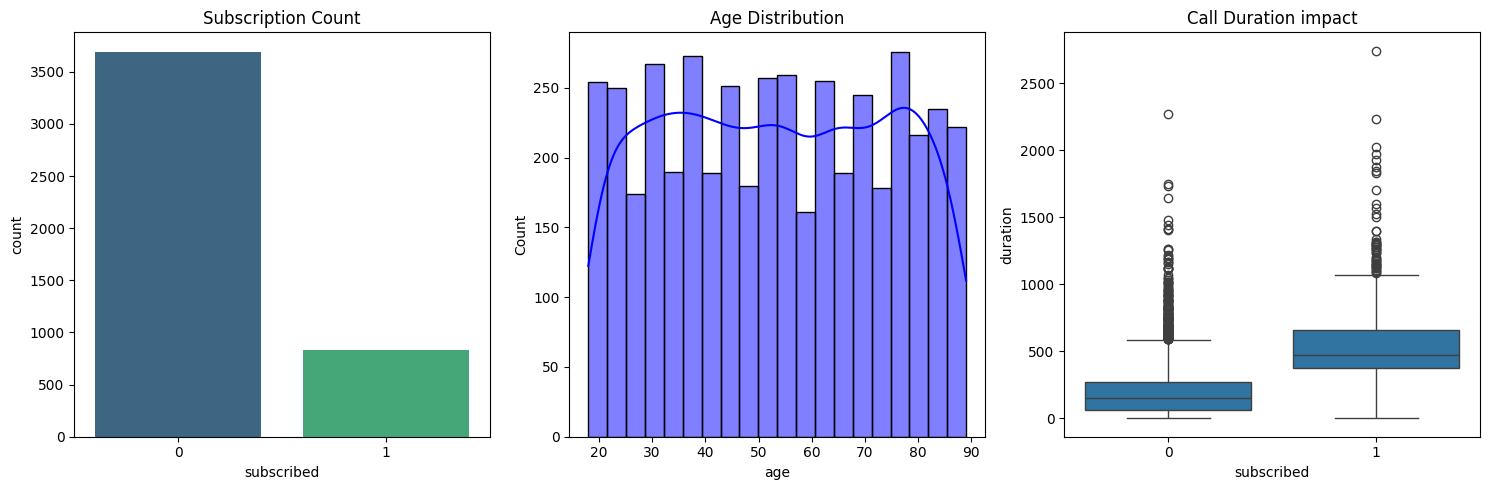

In [15]:
print("\n" + "="*70)
print("STEP 3: EXPLORATORY DATA ANALYSIS (Visuals)")
print("="*70)

plt.figure(figsize=(15, 5))

# Subscribed vs Not Subscribed
plt.subplot(1, 3, 1)
sns.countplot(x='subscribed', data=df, palette='viridis')
plt.title('Subscription Count')

# Age Distribution
plt.subplot(1, 3, 2)
sns.histplot(df['age'], bins=20, kde=True, color='blue')
plt.title('Age Distribution')

# Duration vs Subscription
plt.subplot(1, 3, 3)
sns.boxplot(x='subscribed', y='duration', data=df)
plt.title('Call Duration impact')

plt.tight_layout()
plt.show()

**MODEL TRANING AND EVALUATION**


STEP 4: MODEL TRAINING & PERFORMANCE
🚀 Model Performance:
   -> F1-Score: 0.5377
   -> ROC-AUC:  0.9180


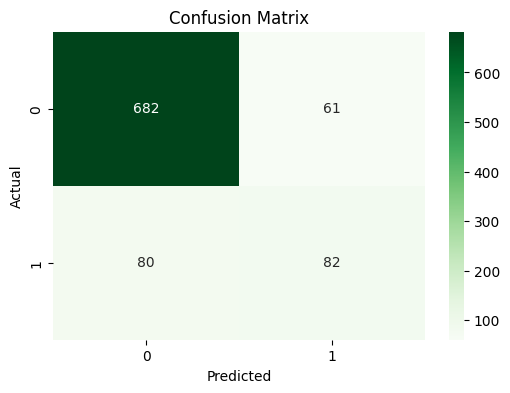

In [16]:
print("\n" + "="*70)
print("STEP 4: MODEL TRAINING & PERFORMANCE")
print("="*70)

# Random Forest Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

print(f"🚀 Model Performance:")
print(f"   -> F1-Score: {f1:.4f}")
print(f"   -> ROC-AUC:  {auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**CONCULSION**

In [17]:
### **📌 Key Takeaways**

takeaways = """📌 Key Takeaways

- Top Predictor: The Duration of the call is the most important factor. Longer calls usually result in a "Yes".
- Efficiency: Using the Random Forest model, we can accurately identify potential customers, reducing unnecessary calls.
- Advice: The bank should focus on customers who have had successful outcomes in previous campaigns.

Task 1 Completed Successfully! ✅
"""
print(takeaways)



📌 Key Takeaways

- Top Predictor: The Duration of the call is the most important factor. Longer calls usually result in a "Yes".
- Efficiency: Using the Random Forest model, we can accurately identify potential customers, reducing unnecessary calls.
- Advice: The bank should focus on customers who have had successful outcomes in previous campaigns.

Task 1 Completed Successfully! ✅

